In [334]:
import pandas as pd
import os
import xml.etree.ElementTree as ET

from ast import literal_eval

POLARITIES_MAPPING = {'positive': 'POSITIVE', 'neutral': 'NEUTRAL', 'negative': 'NEGATIVE'}

def readDataset(path):
    tree = ET.parse(path)
    root = tree.getroot()
    
    annotations = []
    sample_id = 0
    
    for doc in root.findall('.//sentence'):
        text = doc.find('.//text').text
        label_list = []
        label_list_phrases = []

        sample_id = doc.get('id')
        opinions = doc.findall('.//Opinion')
        if opinions:
            for op in doc.findall('.//Opinion'):
                # aspect = op.get('category').split('#')[0]
                aspect = op.get('category')
                # for key in ASPECTS_MAPPING.keys():
                #     aspect = aspect.replace(key, ASPECTS_MAPPING[key])
                polarity = op.get('polarity')
                for key in POLARITIES_MAPPING.keys():
                    polarity = polarity.replace(key, POLARITIES_MAPPING[key])

                phrase = op.get("target", "")
                # phrase = phrase.replace('"', '')
                
                label_list.append((aspect.replace('#',' ').lower(), polarity.lower(), phrase))
            
        
            annotations.append([sample_id, text, label_list])
    return annotations
    
def convert_to_list_of_tuples(data):
    try:
        parsed_data = literal_eval(data) if isinstance(data, str) else data
        
        if isinstance(parsed_data, list):
            return [literal_eval(item) if isinstance(item, str) else item for item in parsed_data]
        
        return parsed_data
    except (ValueError, SyntaxError):
        return None
        
def loadDataset(data_path):

    converters = {'labels': convert_to_list_of_tuples}
    
    df_train = pd.read_csv(os.path.join(data_path, 'train.tsv'), sep='\t', converters=converters).set_index('id')
    df_eval = pd.read_csv(os.path.join(data_path, 'test.tsv'), sep='\t', converters=converters).set_index('id')
        
    return df_train, df_eval

In [335]:
###
#   Transform original SemEval data to json-format
###

PATH = '../data/restaurant/'

def filterConflict(labels):
    return True in [pol == 'conflict' for asp, pol, phr in labels]
    
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

print(dataset_folders)
for folder in dataset_folders:
    try:
        annotations_train = readDataset(os.path.join(PATH, folder, 'train.xml'))
        annotations_test = readDataset(os.path.join(PATH, folder, 'test.xml'))
        
        columns = ['id', 'text', 'labels']
        
        train = pd.DataFrame(annotations_train, columns = columns)
        test = pd.DataFrame(annotations_test, columns = columns)
        
        train = train[~train['labels'].apply(filterConflict)]
        test = test[~test['labels'].apply(filterConflict)]

        os.makedirs(f'../data/restaurant/{folder}', exist_ok=True)
        
        if True:
            train.to_csv(f'../data/restaurant/{folder}/train.tsv', encoding = 'utf-8', sep = '\t', index=False)
            test.to_csv(f'../data/restaurant/{folder}/test.tsv', encoding = 'utf-8', sep = '\t', index=False)
            train.to_json(f'../data/restaurant/{folder}/train.json', orient="records", lines=True)
            test.to_json(f'../data/restaurant/{folder}/test.json', orient="records", lines=True)
    except:
        print("No files found for lang: ", folder)

['nl', 'tr', 'ru', 'es', 'fr', 'cs', 'en', 'de']
No files found for lang:  de


In [420]:
###
#   Create custom GERestaurant dataset for annotation 
#   Select samples not yet annotated by Hellwig et al.
###

import pandas as pd
import ast
import re

def parse_gerest(file_path):
    """
    Parses a custom dataset formatted with '####' as a separator.

    Args:
        file_path (str): Path to the dataset file.

    Returns:
        pd.DataFrame: A DataFrame with two columns: 'Text' and 'Annotations'.
    """
    # Read the file into a DataFrame
    df = pd.read_csv(file_path, sep='####', header=None, names=['text', 'labels'], engine='python')
    
    # Convert the 'Annotations' column into a list of tuples
    def convert_annotations(annotations):
        try:
            return [tuple(item) for item in ast.literal_eval(annotations)]
        except (ValueError, SyntaxError):
            return None  # Handle malformed data gracefully

    # Apply the conversion function to the 'Annotations' column
    df['labels'] = df['labels'].apply(convert_annotations)
    
    return df

# Parsing original GERestaurant with 5 classes
def parse_annotations_gerestaurant(annotation_str):
    """Parses aspect annotations into a list of tuples from dataset without subaspects."""
    try:
        # Remove outer brackets and extract content inside parentheses
        annotation_str = annotation_str.strip("[]")  # Remove outer brackets
        matches = re.findall(r"\(([^)]+)\)", annotation_str)  # Extract tuples from parentheses
        
        # Parse each extracted match into a tuple
        parsed_annotations = []
        for match in matches:
            elements = [elem.strip().strip('"') for elem in match.split(",")]  # Split and clean elements
            if len(elements) == 3:  # Ensure only valid (ASPECT, POLARITY, PHRASE) tuples
                parsed_annotations.append(tuple(elements))
        
        return parsed_annotations
    except Exception as e:
        print(f"Parsing failed for without-subaspects annotations: {annotation_str} - Error: {e}")
        return []

split = 'train'
        
path_gerest = os.path.join(PATH, 'de', f'{split}.txt')
df_gerest = parse_gerest(path_gerest)

# Load the dataset without subaspects
path_gerestaurant = os.path.join(PATH, 'de', f'{split}_5sub.tsv')
df_gerestaurant = pd.read_csv(path_gerestaurant, sep='\t')

# Apply parsing function
df_gerestaurant['labels_phrases'] = df_gerestaurant['labels_phrases'].apply(parse_annotations_gerestaurant)
df_gerestaurant = df_gerestaurant[['text', 'labels_phrases']] 
df_gerestaurant.columns = ['text', 'labels']

df_overlap = pd.concat([df_gerest, df_gerestaurant]).drop_duplicates(subset='text', keep=False)

columns = ['labels_' + str(i) for i in range(df_overlap['labels'].apply(len).max())]
df_overlap[columns] = pd.DataFrame(df_overlap.labels.tolist(), index= df_overlap.index)

df_overlap = df_overlap.drop(['labels'], axis = 1)
df_overlap = df_overlap.fillna(value="")

df_text_only = df_overlap[['text']].copy()  # Keep only the text column
for col in columns:
    df_text_only[col] = ""  # Set all label columns to None
        
df_annotation = pd.concat([df_overlap, df_text_only], ignore_index=True).sort_values(by=['text', 'labels_0']).reset_index(drop=True)
df_annotation.to_csv(os.path.join(PATH, 'de', f'annotations_{split}.csv'), encoding = 'utf-8')

In [701]:
###
#  Merge annotations with original dataset
###

import numpy as np

aspect_dict = {
    'rg': 'restaurant general',
    'rm': 'restaurant miscellaneous',
    'rp': 'restaurant prices',
    'fq': 'food quality',
    'fs': 'food style_options',
    'fp': 'food prices',
    'dq': 'drinks quality',
    'ds': 'drinks style_options',
    'dp': 'drinks prices',
    'sg': 'service general',
    'ag': 'ambience general',
    'lg': 'location general'
}

def convertAnnotations(cell):
    try:
        return ast.literal_eval(cell)
    except:
        return cell
        
split = 'train'

path_annotations = os.path.join(PATH, 'de', f'annotations_{split}_finished.tsv')
df_annotations = pd.read_csv(path_annotations, sep = '\t', index_col = 0, encoding = 'utf_8', quoting =3)

label_cols = df_annotations.columns[1:]
for col in label_cols:
    df_annotations[col] = df_annotations[col].apply(convertAnnotations)

path_gerest = os.path.join(PATH, 'de', f'{split}.txt')
df_gerest = parse_gerest(path_gerest)

rows_cleaned = []

# Iterate over pairs of rows (original + annotation)
for i in range(0, len(df_annotations), 2):
    if i + 1 >= len(df_annotations):  # Ensure we don't go out of bounds
        break

    row_orig = df_annotations.iloc[i].copy()
    row_new = df_annotations.iloc[i + 1]

    annotated_cols = [col for col in df_annotations.columns[1:] if pd.notna(row_new[col])]

    for col in annotated_cols:
        if pd.notna(row_orig[col]):  # Ensure the original cell contains valid data
            aspect = aspect_dict.get(row_new[col], row_new[col])  # Map aspect, fallback to original if missing
            row_orig[col] = (aspect, row_orig[col][1], row_orig[col][2])

    rows_cleaned.append(row_orig)
    
def condenseLabels(row):
    labels = []
    for col in label_cols:
        if row[col] is not np.nan:
            
            labels.append((row[col][0], row[col][1].lower(), row[col][2]))
    return labels
    
# Convert back to DataFrame
df_annotations_cleaned = pd.DataFrame(rows_cleaned)
df_annotations_cleaned['labels'] = df_annotations_cleaned.apply(condenseLabels, axis = 1)
df_annotations_cleaned.drop(inplace=True, columns = label_cols)

def reorderLabels(labels):
    labels_new = []
    for lab in labels:
        labels_new.append([lab[1], lab[2] ,lab[0]])
    return labels_new

df_gerest['labels'] = df_gerest['labels'].apply(reorderLabels)

df_combined = pd.concat([df_annotations_cleaned, df_gerest]).reset_index()
df_combined.drop(inplace=True, columns = ['index'])
df_combined.index.name = 'id'
df_combined.reset_index().to_json(os.path.join(PATH, 'de', f'{split}.json'), orient="records", lines=True)

In [936]:
counters_new = {}
len_dfs = {}
for lang, df in dfs_lang.items():
    print(lang)
    print(len(df))
    len_dfs[lang] = len(df)
    c = Counter([asp for labels in df['labels'] for asp, pol, phr in labels])
    counters_new[lang] = c
    print(c)
    print(sum(c.values()))

nl
1087
Counter({'food quality': 510, 'service general': 334, 'restaurant general': 257, 'ambience general': 179, 'food style_options': 142, 'drinks quality': 47, 'restaurant prices': 46, 'food prices': 30, 'location general': 25, 'drinks style_options': 21, 'drinks prices': 13, 'restaurant miscellaneous': 13})
1617
ru
1153
Counter({'food quality': 634, 'service general': 389, 'ambience general': 277, 'restaurant general': 259, 'food style_options': 180, 'restaurant prices': 52, 'drinks quality': 51, 'food prices': 37, 'location general': 27, 'drinks style_options': 26, 'drinks prices': 17, 'restaurant miscellaneous': 14})
1963
es
951
Counter({'food quality': 574, 'service general': 362, 'restaurant general': 275, 'ambience general': 213, 'food style_options': 150, 'food prices': 78, 'restaurant prices': 64, 'drinks quality': 30, 'drinks style_options': 21, 'location general': 15, 'drinks prices': 12, 'restaurant miscellaneous': 12})
1806
fr
1020
Counter({'food quality': 549, 'service 

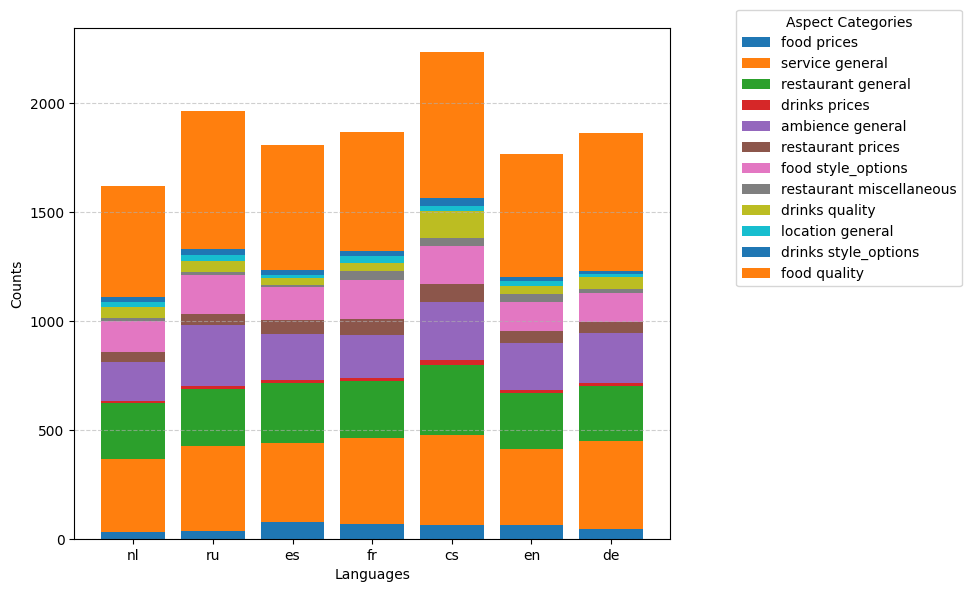

In [912]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Extrahiere die Sprachen und Kategorien
languages = list(balanced_counters_asp.keys())  # Sprachkürzel als X-Achse
categories = list(next(iter(balanced_counters_asp.values())).keys())  # Kategorien (Keys der Counter)

# Erstelle die Datenmatrix (Counts für jede Sprache und Kategorie)
values = np.array([[counter[cat] for cat in categories] for counter in balanced_counters_asp.values()])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Stapel-Balken zeichnen
bottoms = np.zeros(len(languages))  # Anfangshöhe der gestapelten Balken (initial 0)
for i, category in enumerate(categories):
    ax.bar(languages, values[:, i], label=category, bottom=bottoms)
    bottoms += values[:, i]  # Aktualisiere die Höhe für den nächsten Stapel

# Achsen und Titel
ax.set_xlabel("Languages")
ax.set_ylabel("Counts")
ax.legend(title="Aspect Categories", bbox_to_anchor=(1.1, 1.05))
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Layout
plt.tight_layout()
plt.show()


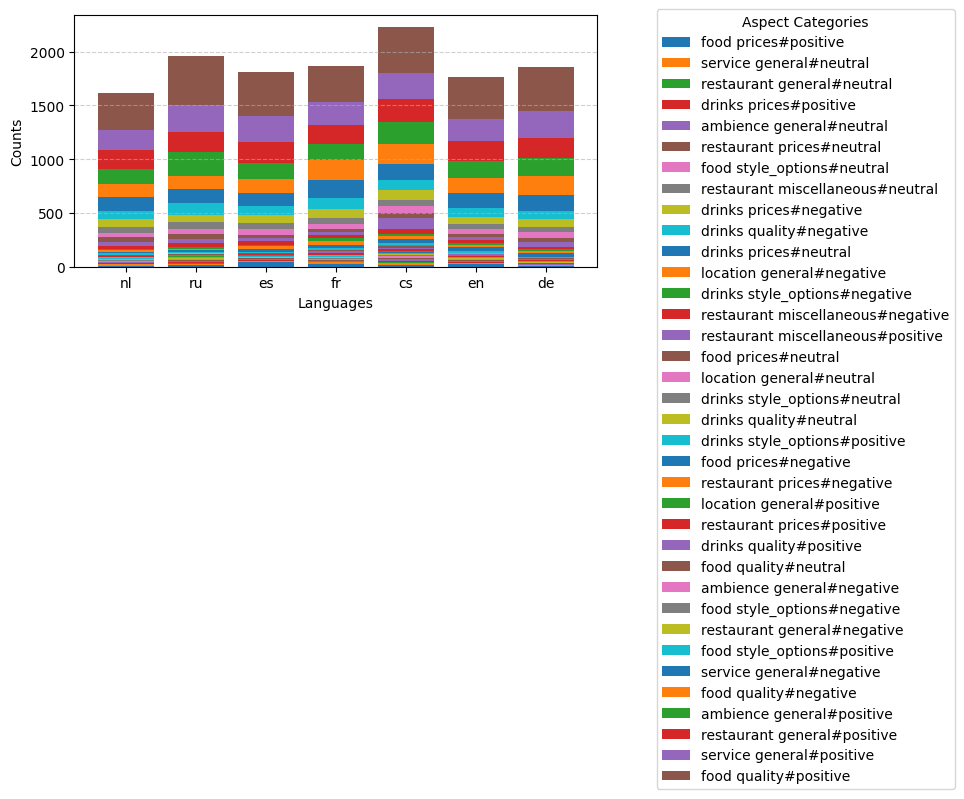

In [913]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Extrahiere die Sprachen und Kategorien
languages = list(balanced_counters_asp_pol.keys())  # Sprachkürzel als X-Achse
categories = list(next(iter(balanced_counters_asp_pol.values())).keys())  # Kategorien (Keys der Counter)

# Erstelle die Datenmatrix (Counts für jede Sprache und Kategorie)
values = np.array([[counter[cat] for cat in categories] for counter in balanced_counters_asp_pol.values()])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Stapel-Balken zeichnen
bottoms = np.zeros(len(languages))  # Anfangshöhe der gestapelten Balken (initial 0)
for i, category in enumerate(categories):
    ax.bar(languages, values[:, i], label=category, bottom=bottoms)
    bottoms += values[:, i]  # Aktualisiere die Höhe für den nächsten Stapel

# Achsen und Titel
ax.set_xlabel("Languages")
ax.set_ylabel("Counts")
ax.legend(title="Aspect Categories", bbox_to_anchor=(1.1, 1.05))
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Layout
plt.tight_layout()
plt.show()


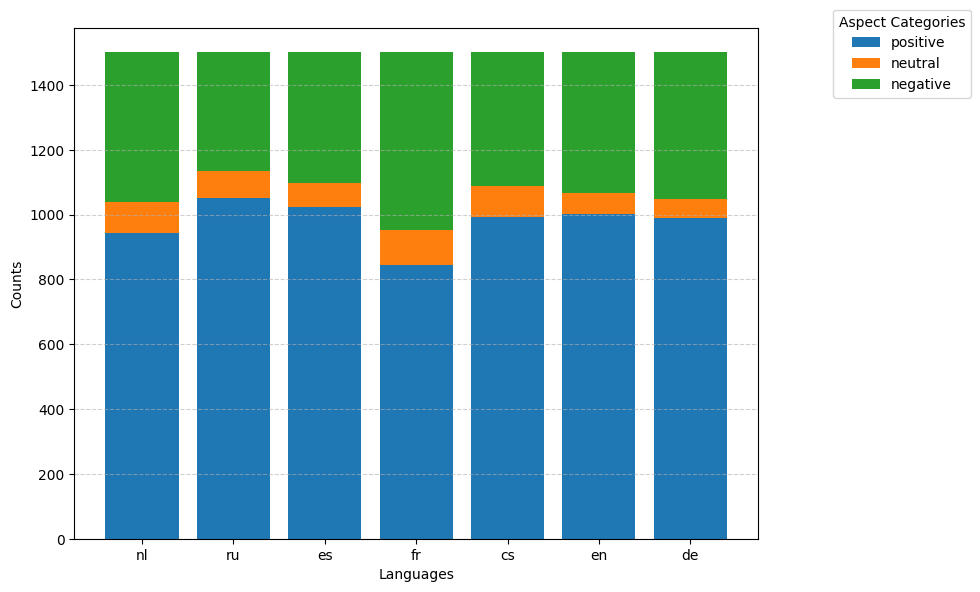

In [949]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Extrahiere die Sprachen und Kategorien
languages = list(balanced_counters_pol.keys())  # Sprachkürzel als X-Achse
categories = list(next(iter(balanced_counters_pol.values())).keys())  # Kategorien (Keys der Counter)

# Erstelle die Datenmatrix (Counts für jede Sprache und Kategorie)
values = np.array([[counter[cat] for cat in categories] for counter in balanced_counters_pol.values()])
values = values / values.sum(axis=1, keepdims=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Stapel-Balken zeichnen
bottoms = np.zeros(len(languages))  # Anfangshöhe der gestapelten Balken (initial 0)
for i, category in enumerate(categories):
    ax.bar(languages, 1500*values[:, i], label=category, bottom=bottoms)
    bottoms += 1500*values[:, i]  # Aktualisiere die Höhe für den nächsten Stapel

# Achsen und Titel
ax.set_xlabel("Languages")
ax.set_ylabel("Counts")
ax.legend(title="Aspect Categories", bbox_to_anchor=(1.1, 1.05))
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Layout
plt.tight_layout()
plt.show()


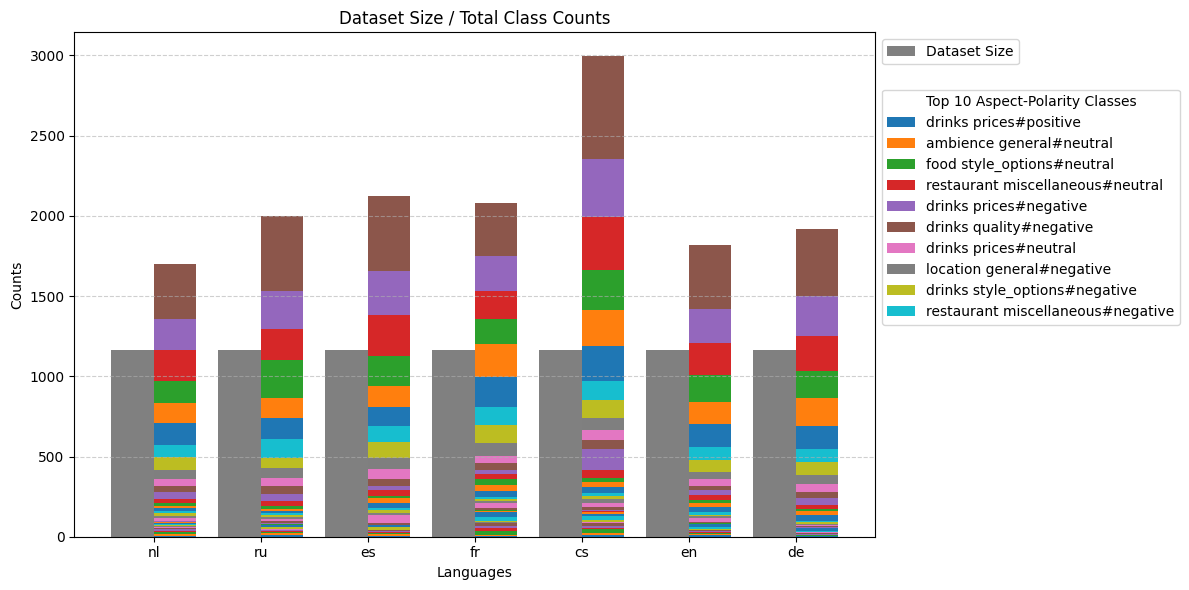

In [117]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Extract languages and categories
languages = list(len_dfs.keys())  # Language codes for X-axis
categories = list(next(iter(balanced_counters_asp_pol.values())).keys())  # Categories (Keys from Counter)

# Create data matrix (counts for each language and category)
values = np.array([[counter.get(cat, 0) for cat in categories] for counter in balanced_counters_asp_pol.values()])

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx() 

# Bar width for grouped bars
bar_width = 0.4  
x_indexes = np.arange(len(languages))  # X positions for bars

# Plot total counts as solid bars (left bars for each language)
bars1 = ax.bar(x_indexes - bar_width / 2, len_dfs.values(), width=bar_width, color='gray', label="Total Count")

bars2 = []
# Plot stacked bars (right bars for each language)
bottoms = np.zeros(len(languages))  # Initial height for stacking
for i, category in enumerate(categories):
    bars2.append(ax.bar(x_indexes + bar_width / 2, values[:, i], width=bar_width, label=category, bottom=bottoms)[0])
    bottoms += values[:, i]  # Update heights for next stack
    ax2.bar(x_indexes + bar_width / 2, values[:, i], width=bar_width, label=category, bottom=bottoms)
    
# Labels and formatting
ax.set_xticks(x_indexes)
ax.set_xticklabels(languages)
ax.set_xlabel("Languages")
ax.set_ylabel("Counts")
ax.set_title("Dataset Size / Total Class Counts")
# ax.legend(title="Aspect Categories", bbox_to_anchor=(1.05, 1), loc="upper left")

legend1 = ax.legend([bars1], ["Dataset Size"], bbox_to_anchor=(1, 1), loc="upper left", fontsize=10)
ax.add_artist(legend1)

handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles2
labels = labels2

top_n = 10  
if len(labels) > top_n:
    handles = handles[:top_n]
    labels = labels[:top_n]

legend2 = ax.legend(handles, labels, title="Top 10 Aspect-Polarity Classes", loc="upper left", bbox_to_anchor=(1, 0.9), fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.6)

# Show plot
plt.tight_layout()
plt.show()


In [242]:
###
#   Create Dataset splits for balanced datasets
###


import os
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.utils import shuffle

PATH = '../data/restaurant/'
SPLIT = 'train'

# Lade die Datensätze
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) 
                   if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

dfs = {}
counters_asp_pol = {}

for folder in dataset_folders:        
    if folder != 'tr':
        df_train = pd.read_json(os.path.join(PATH, folder, f'{SPLIT}.json'), orient="records", lines=True).set_index('id')
        asp_pol = [f'{aspect}#{polarity}' for labels in df_train['labels'] for aspect, polarity, phrase in labels]
        counters_asp_pol[folder] = Counter(asp_pol)
        dfs[folder] = df_train

all_counts_asp_pol = {}

# Berechne die Häufigkeiten über alle Sprachen
for lang, counter in counters_asp_pol.items():
    for attribute, value in counter.items():
        if attribute not in all_counts_asp_pol:
            all_counts_asp_pol[attribute] = []
        all_counts_asp_pol[attribute].append(value)

# **Berechne die ideale Verteilung jeder Klasse**
global_min_class_count = {cls: max(5, min(v)) for cls, v in all_counts_asp_pol.items()}
sorted_lowest_asp_pol = sorted(global_min_class_count.items(), key=lambda x: x[1])
total_samples = sum(global_min_class_count.values())  # Gesamtsumme aller Klassenhäufigkeiten
ideal_distribution = {cls: count / total_samples for cls, count in global_min_class_count.items()}  # Prozentuale Zielwerte

# Initialisiere die balancierten Datensätze
balanced_langs = {lang: pd.DataFrame(columns=dfs[lang].columns) for lang in dfs.keys()}

def filterAspPol(labels, asp_pol):
    return asp_pol in [f'{asp}#{pol}' for asp, pol, phr in labels]

# **1. Erstes Sampling basierend auf `global_min_class_count`**
for asp_pol, count in sorted_lowest_asp_pol:
    for lang, df in dfs.items():
        df_subset = df[df['labels'].apply(lambda x: filterAspPol(x, asp_pol))]
        df_already_in = df_subset.index.isin(balanced_langs[lang][balanced_langs[lang]['labels'].apply(lambda x: filterAspPol(x, asp_pol))].index)
        df_subset = df_subset[~df_already_in]

        if len(df_subset) >= (count - sum(df_already_in) if count - sum(df_already_in) > 0 else 0):
            df_sample = df_subset.sample(n=(count - sum(df_already_in) if count - sum(df_already_in) > 0 else 0), random_state=10)
        else:
            df_sample = df_subset

        balanced_langs[lang] = pd.concat([balanced_langs[lang], df_sample])

# **2. Bestimme die maximale Datensatzgröße nach dem ersten Sampling**
max_size = max(len(df) for df in balanced_langs.values())

# **3. Iteratives Nachsampling mit optimaler Verteilung**
for lang, df in balanced_langs.items():
    if len(df) < max_size:
        remaining_needed = max_size - len(df)
        
        df_available = dfs[lang][~dfs[lang].index.isin(df.index)]  # Verbleibende nicht gewählte Beispiele
        df_available = shuffle(df_available, random_state=42)  # Zufällige Reihenfolge
        
        selected_samples = []
        
        while len(df) < max_size:
            # **Berechne aktuelle relative Klassenverteilung**
            current_class_counts = Counter(f"{asp}#{pol}" for labels in df["labels"] for asp, pol, phr in labels)
            total_current_samples = sum(current_class_counts.values()) if sum(current_class_counts.values()) > 0 else 1
            current_distribution = {cls: count / total_current_samples for cls, count in current_class_counts.items()}

            # **Berechne die Abweichung zur idealen Verteilung**
            class_diff = {cls: ideal_distribution[cls] - current_distribution.get(cls, 0) for cls in ideal_distribution}

            # **Sortiere Klassen nach größter prozentualer Abweichung**
            sorted_classes = sorted(class_diff.keys(), key=lambda cls: class_diff[cls], reverse=True)

            # **Finde die erste Klasse mit verfügbaren Kandidaten**
            best_sample = None
            for candidate_class in sorted_classes:
                df_candidates = df_available[df_available["labels"].apply(lambda x: filterAspPol(x, candidate_class))]
                if not df_candidates.empty:
                    best_sample = df_candidates.sample(1, random_state=42)
                    break  # Sobald eine passende Klasse gefunden wurde, abbrechen
            
            if best_sample is None:
                break  # Falls keine Samples mehr verfügbar sind, abbrechen

            # **Füge das gewählte Sample zum balancierten Datensatz hinzu**
            selected_samples.append(best_sample)
            
            # **Entferne das gewählte Sample aus der verfügbaren Liste**
            df_available = df_available.drop(best_sample.index)

            # **Aktualisiere die Verteilung**
            df = pd.concat([df, best_sample])

            # **Falls bereits genug nachgesampelt wurde, abbrechen**
            if len(df) >= max_size:
                break

        # **Füge die ausgewählten zusätzlichen Beispiele hinzu**
        balanced_langs[lang] = df

# **Ergebnis: `balanced_langs` enthält für jede Sprache ein perfekt balanciertes DataFrame**
summary_df = pd.DataFrame({lang: len(df) for lang, df in balanced_langs.items()}, index=["Final Sample Size"]).T
print(summary_df)




len_dfs = {}
for lang, df in balanced_langs.items():
    len_dfs[lang] = len(df)

for lang, df in balanced_langs.items():
    balanced_langs[lang].insert(0, 'id', balanced_langs[lang].index)

    if False: # Do not save again
        balanced_langs[lang].to_json(os.path.join(PATH, f'{lang}/{SPLIT}_b.json'), orient="records", lines=True)

balanced_counters_asp = {}
balanced_counters_asp_pol = {}
balanced_counters_pol = {}

for asp_pol, count in sorted_lowest_asp_pol:
    for lang, df in dfs.items():
        if lang not in balanced_counters_asp:
            balanced_counters_asp[lang] = {}
        if lang not in balanced_counters_asp_pol:
            balanced_counters_asp_pol[lang] = {}
        if lang not in balanced_counters_pol:
            balanced_counters_pol[lang] = {}
        balanced_counters_asp[lang][asp_pol.split('#')[0]] = len([asp for labels in balanced_langs[lang]['labels'] for asp, pol, phr in labels if asp == asp_pol.split('#')[0]])
        balanced_counters_asp_pol[lang][asp_pol] = len([f'{asp}#{pol}' for labels in balanced_langs[lang]['labels'] for asp, pol, phr in labels if f'{asp}#{pol}' == asp_pol])
        balanced_counters_pol[lang][asp_pol.split('#')[1]] = len([pol for labels in balanced_langs[lang]['labels'] for asp, pol, phr in labels if pol == asp_pol.split('#')[1]])

    Final Sample Size
nl               1162
ru               1162
es               1162
fr               1162
cs               1162
en               1162
de               1162


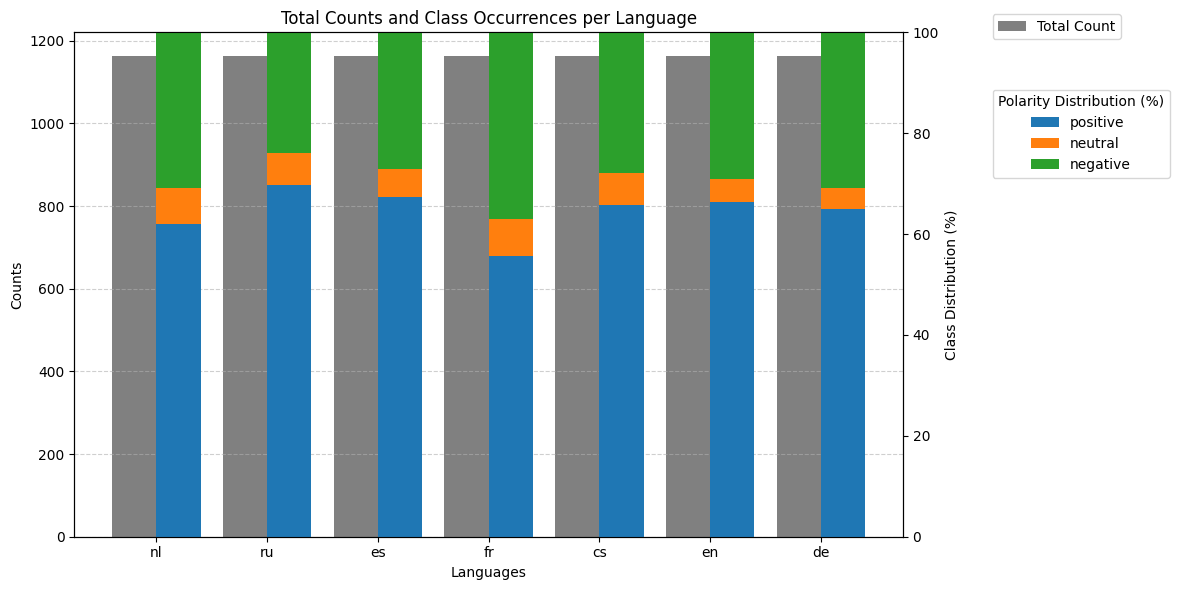

In [119]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Extract languages and categories
languages = list(len_dfs.keys())  # Language codes for X-axis
categories = list(next(iter(balanced_counters_pol.values())).keys())  # Categories (Keys from Counter)

# Create data matrix (counts for each language and category)
values = np.array([[counter.get(cat, 0) for cat in categories] for counter in balanced_counters_pol.values()])
values = values / values.sum(axis=1, keepdims=True)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx() 

# Bar width for grouped bars
bar_width = 0.4  
x_indexes = np.arange(len(languages))  # X positions for bars

# Plot total counts as solid bars (left bars for each language)
ax1.bar(x_indexes - bar_width / 2, len_dfs.values(), width=bar_width, color='gray', label="Total Count")

# Plot stacked bars (right bars for each language)
bottoms = np.zeros(len(languages))  # Initial height for stacking
for i, category in enumerate(categories):
    ax2.bar(x_indexes + bar_width / 2, 100*values[:, i], width=bar_width, label=category, bottom=bottoms)
    bottoms += 100*values[:, i]  # Update heights for next stack

# Labels and formatting
ax1.set_xticks(x_indexes)
ax1.set_xticklabels(languages)
ax1.set_xlabel("Languages")
ax1.set_ylabel("Counts")
ax2.set_ylabel("Class Distribution (%)")
ax1.set_title("Total Counts and Class Occurrences per Language")
ax1.legend(bbox_to_anchor=(1.1, 1.05), loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.6)
# ax2.legend(title="Aspect-Polarity Classes", loc="upper left", bbox_to_anchor=(1.1, 0.9), fontsize= 9)

handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles2
labels = labels2

top_n = 10  
if len(labels) > top_n:
    handles = handles[:top_n]
    labels = labels[:top_n]

ax2.legend(handles, labels, title="Polarity Distribution (%)", loc="upper left", bbox_to_anchor=(1.1, 0.9), fontsize=10)
ax2.set_ylim(0, 100)

# Show plot
plt.tight_layout()
plt.show()

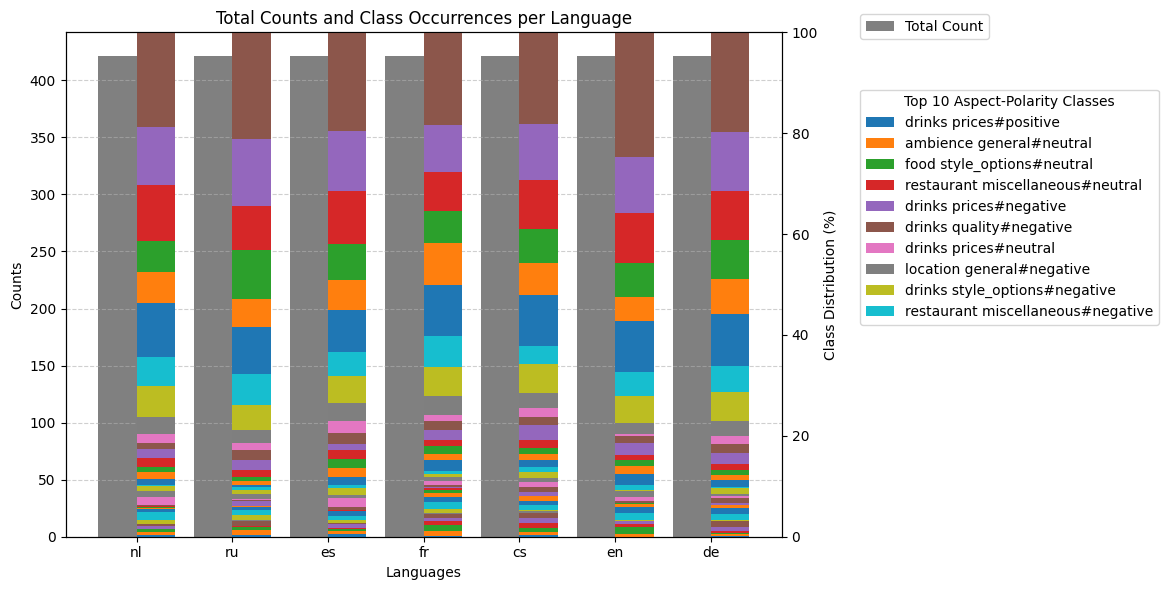

In [191]:
###
#   Analyse ratios of original dataset
###

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

PATH = '../data/restaurant/'
SPLIT = 'test_b'

# Lade die Datensätze
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) 
                   if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

len_dfs = {}
dfs = {}
for folder in dataset_folders:      
    try:
        df = pd.read_json(os.path.join(PATH, folder, f'{SPLIT}.json'), orient="records", lines=True).set_index('id')
        dfs[folder] = df
        len_dfs[folder] = len(df)
    except:
        pass

counters_asp = {}
counters_asp_pol = {}
counters_pol = {}

for asp_pol, count in sorted_lowest_asp_pol:
    for lang, df in dfs.items():
        if lang not in counters_asp:
            counters_asp[lang] = {}
        if lang not in counters_asp_pol:
            counters_asp_pol[lang] = {}
        if lang not in counters_pol:
            counters_pol[lang] = {}
        counters_asp[lang][asp_pol.split('#')[0]] = len([asp for labels in dfs[lang]['labels'] for asp, pol, phr in labels if asp == asp_pol.split('#')[0]])
        counters_asp_pol[lang][asp_pol] = len([f'{asp}#{pol}' for labels in dfs[lang]['labels'] for asp, pol, phr in labels if f'{asp}#{pol}' == asp_pol])
        counters_pol[lang][asp_pol.split('#')[1]] = len([pol for labels in dfs[lang]['labels'] for asp, pol, phr in labels if pol == asp_pol.split('#')[1]])

# Extract languages and categories
languages = list(len_dfs.keys())  # Language codes for X-axis
categories = list(next(iter(counters_asp_pol.values())).keys())  # Categories (Keys from Counter)

# Create data matrix (counts for each language and category)
values = np.array([[counter.get(cat, 0) for cat in categories] for counter in counters_asp_pol.values()])
values = values / values.sum(axis=1, keepdims=True)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx() 

# Bar width for grouped bars
bar_width = 0.4  
x_indexes = np.arange(len(languages))  # X positions for bars

# Plot total counts as solid bars (left bars for each language)
ax1.bar(x_indexes - bar_width / 2, len_dfs.values(), width=bar_width, color='gray', label="Total Count")

# Plot stacked bars (right bars for each language)
bottoms = np.zeros(len(languages))  # Initial height for stacking
for i, category in enumerate(categories):
    ax2.bar(x_indexes + bar_width / 2, 100*values[:, i], width=bar_width, label=category, bottom=bottoms)
    bottoms += 100*values[:, i]  # Update heights for next stack

# Labels and formatting
ax1.set_xticks(x_indexes)
ax1.set_xticklabels(languages)
ax1.set_xlabel("Languages")
ax1.set_ylabel("Counts")
ax2.set_ylabel("Class Distribution (%)")
ax1.set_title("Total Counts and Class Occurrences per Language")
ax1.legend(bbox_to_anchor=(1.1, 1.05), loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.6)
# ax2.legend(title="Aspect-Polarity Classes", loc="upper left", bbox_to_anchor=(1.1, 0.9), fontsize= 9)

handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles2
labels = labels2

top_n = 10  
if len(labels) > top_n:
    handles = handles[:top_n]
    labels = labels[:top_n]

ax2.legend(handles, labels, title="Top 10 Aspect-Polarity Classes", loc="upper left", bbox_to_anchor=(1.1, 0.9), fontsize=10)
ax2.set_ylim(0, 100)

# Show plot
plt.tight_layout()
plt.show()


In [1023]:
from transformers import T5Tokenizer

# Lade den T5-Base Tokenizer
tokenizer = T5Tokenizer.from_pretrained("google/mt5-small")

# Beispiel: ID -> Token
token_id = 259  # Ersetze mit der gewünschten Token-ID
token = tokenizer.convert_ids_to_tokens([8938, 3738, 1, 8314, 24862, 1, 8314, 7814, 1, 8314, 3738, 1, 57099, 6257, 3738, 1, 2945, 3738, 1, 13306, 24862, 1, 20561, 263, 24862, 1, 13306, 1834, 23408, 321, 91849, 1, 20561, 263, 7814, 1, 20561, 263, 4753, 290, 15654, 1, 13306, 3738, 1, 8314, 4753, 290, 15654, 1, 3005, 1, 6201, 1, 5412, 1, 491, 399, 155719, 439, 1])

print(f"Token für ID {token_id}: {token}")


Token für ID 259: ['▁location', '▁general', '</s>', '▁food', '▁prices', '</s>', '▁food', '▁quality', '</s>', '▁food', '▁general', '</s>', '▁ambi', 'ence', '▁general', '</s>', '▁service', '▁general', '</s>', '▁restaurant', '▁prices', '</s>', '▁drink', 's', '▁prices', '</s>', '▁restaurant', '▁mis', 'cell', 'an', 'eous', '</s>', '▁drink', 's', '▁quality', '</s>', '▁drink', 's', '▁style', '_', 'options', '</s>', '▁restaurant', '▁general', '</s>', '▁food', '▁style', '_', 'options', '</s>', '▁great', '</s>', '▁bad', '</s>', '▁ok', '</s>', '▁[', 'S', 'SEP', ']', '</s>']


In [187]:
from transformers import T5Tokenizer

tokenizer_t5 = AutoTokenizer.from_pretrained('yhavinga/t5-v1.1-base-dutch-cased')

to_id = {
            '[O': [667],
            '[A': [188],
            '[S': [134],
            '[C': [254],
            '[SS': [4256],
            'EP]': [8569],
            '[': [784],
            ']': [908],
            'it': [34],
            'null': [206,195]
        }

for phr, ids in to_id.items():
    t5base = tokenizer_t5.convert_ids_to_tokens(ids)
    print(t5base)
    print(tokenizer_t5(phr, return_tensors='pt')['input_ids'])
 

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


['▁straat']
tensor([[   3, 2981,  166,    1]])
['▁zeggen']
tensor([[   3, 2981,  324,    1]])
['▁zien']
tensor([[   3, 2981,  609,    1]])
['▁zoals']
tensor([[   3, 2981, 1367,    1]])
['▁haatt']
tensor([[    3,  2981, 13614,     1]])
['▁maten']
tensor([[   3,  135, 1021, 2947,    1]])
['verdwenen']
tensor([[   3, 2981,    1]])
['ens']
tensor([[   3, 2947,    1]])
['▁om']
tensor([[ 3, 54, 10,  1]])
['▁alsof', '▁omdat']
tensor([[   3,    7, 8916,    1]])


In [341]:
from transformers import T5Tokenizer, AutoTokenizer
tokenizer_t5 = AutoTokenizer.from_pretrained('yhavinga/t5-v1.1-base-dutch-cased')

for phr in ['[O','[A','[S','[C','[SS','[SSEP]', 'EP]', '[EP', '[', ']' , 'it', 'null']:
    print(tokenizer_t5(phr, return_tensors='pt')['input_ids'])

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


tensor([[   3, 2981,  166,    1]])
tensor([[   3, 2981,  324,    1]])
tensor([[   3, 2981,  609,    1]])
tensor([[   3, 2981, 1367,    1]])
tensor([[    3,  2981, 13614,     1]])
tensor([[    3,  2981, 13614,   135,  1021,  2947,     1]])
tensor([[   3,  135, 1021, 2947,    1]])
tensor([[   3, 2981,  135, 1021,    1]])
tensor([[   3, 2981,    1]])
tensor([[   3, 2947,    1]])
tensor([[ 3, 54, 10,  1]])
tensor([[   3,    7, 8916,    1]])


In [179]:
from transformers import MT5Tokenizer, AutoTokenizer
tokenizer_t5 = T5Tokenizer.from_pretrained('ai-forever/ruT5-base')

for phr in ['[O','[A','[S','[C',' [SSEP] ', '[EP', '[', ']', 'null']:
    print(tokenizer_t5(phr, return_tensors='pt')['input_ids'])

tensor([[ 813, 1446,    2]])
tensor([[ 813, 1047,    2]])
tensor([[813, 779,   2]])
tensor([[813, 898,   2]])
tensor([[  813, 13443,  1383,   856,   678,     2]])
tensor([[ 813, 1383,  856,    2]])
tensor([[813,   2]])
tensor([[  8, 678,   2]])
tensor([[ 4859, 17830,     2]])


In [173]:
tokenizer_t5base = T5Tokenizer.from_pretrained('vgaraujov/t5-base-spanish')
print(tokenizer_t5base(['null'], return_tensors='pt')['input_ids'])

tensor([[12371,     1]])


In [181]:
tokenizer_t5.decode(1383)

'E'

In [18]:
a = []
for phr in ['service general',
 'food quality',
 'restaurant general',
 'food style_options',
 'ambience general',
 'location general',
 'drinks quality',
 'food prices',
 'drinks style_options',
 'drinks prices',
 'restaurant prices',
 'restaurant miscellaneous']:
    print(tokenizer_mt5(phr, return_tensors='pt')['input_ids'])

tensor([[2945, 3738,    1]])
tensor([[8314, 7814,    1]])
tensor([[13306,  3738,     1]])
tensor([[ 8314,  4753,   290, 15654,     1]])
tensor([[57099,  6257,  3738,     1]])
tensor([[8938, 3738,    1]])
tensor([[20561,   263,  7814,     1]])
tensor([[ 8314, 24862,     1]])
tensor([[20561,   263,  4753,   290, 15654,     1]])
tensor([[20561,   263, 24862,     1]])
tensor([[13306, 24862,     1]])
tensor([[13306,  1834, 23408,   321, 91849,     1]])


'SS'

In [17]:
tokenizer_mt5('_', return_tensors='pt')['input_ids']

tensor([[259, 290,   1]])

In [16]:
tokenizer('_', return_tensors='pt')['input_ids']

tensor([[  3, 834,   1]])

In [336]:
PATH = '../data/restaurant/'
SPLIT = 'train_b'

# Lade die Datensätze
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) 
                   if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

dfs = {}
for folder in dataset_folders:      
    try:
        df_tr = pd.read_json(os.path.join(PATH, folder, f'train_b.json'), orient="records", lines=True).set_index('id')
        df_te = pd.read_json(os.path.join(PATH, folder, f'test_b.json'), orient="records", lines=True).set_index('id')
        dfs[folder] = [df_tr, df_te]
    except:
        pass

In [337]:
for lang, [df1, df2] in dfs.items():
    overlap = df1.index.intersection(df2.text)
    if overlap.empty:
        print("✅ Die Datensätze überschneiden sich nicht.")
    else:
        print(f"⚠ Achtung! {len(overlap)} Überschneidungen gefunden: {overlap.tolist()}")


✅ Die Datensätze überschneiden sich nicht.
✅ Die Datensätze überschneiden sich nicht.
✅ Die Datensätze überschneiden sich nicht.
✅ Die Datensätze überschneiden sich nicht.
✅ Die Datensätze überschneiden sich nicht.
✅ Die Datensätze überschneiden sich nicht.
✅ Die Datensätze überschneiden sich nicht.


In [289]:
for lang, [df1, df2] in dfs.items():
    overlap_text = df1.index.isin(df2.index)
    if not overlap_text.any():
        print("✅ Die Texte sind eindeutig in beiden Datensätzen.")
    else:
        print(f"⚠ Achtung! {overlap_text.sum()} doppelte Texte für {lang} gefunden.")

✅ Die Texte sind eindeutig in beiden Datensätzen.
✅ Die Texte sind eindeutig in beiden Datensätzen.
✅ Die Texte sind eindeutig in beiden Datensätzen.
✅ Die Texte sind eindeutig in beiden Datensätzen.
✅ Die Texte sind eindeutig in beiden Datensätzen.
✅ Die Texte sind eindeutig in beiden Datensätzen.
✅ Die Texte sind eindeutig in beiden Datensätzen.


In [276]:
def readDataset(path):
    tree = ET.parse(path)
    root = tree.getroot()
    
    annotations = []
    sample_id = 0

    mapping = {}
    
    for doc in root.findall('.//sentence'):
        text = doc.find('.//text').text
        label_list = []
        label_list_phrases = []

        opinions = doc.findall('.//Opinion')
        if opinions:
            for op in doc.findall('.//Opinion'):
                # aspect = op.get('category').split('#')[0]
                aspect = op.get('category')
                # for key in ASPECTS_MAPPING.keys():
                #     aspect = aspect.replace(key, ASPECTS_MAPPING[key])
                polarity = op.get('polarity')
                for key in POLARITIES_MAPPING.keys():
                    polarity = polarity.replace(key, POLARITIES_MAPPING[key])

                phrase = op.get("target", "")
                phrase = phrase.replace('"', '')
                
                label_list.append((aspect.replace('#',' ').lower(), polarity.lower(), phrase))
            
        
            annotations.append([sample_id, text, label_list])
            mapping[sample_id] = doc.get('id')
            sample_id += 1
    return mapping
    
def convert_to_list_of_tuples(data):
    try:
        parsed_data = literal_eval(data) if isinstance(data, str) else data
        
        if isinstance(parsed_data, list):
            return [literal_eval(item) if isinstance(item, str) else item for item in parsed_data]
        
        return parsed_data
    except (ValueError, SyntaxError):
        return None
        
def loadDataset(data_path):

    converters = {'labels': convert_to_list_of_tuples}
    
    df_train = pd.read_csv(os.path.join(data_path, 'train.tsv'), sep='\t', converters=converters).set_index('id')
    df_eval = pd.read_csv(os.path.join(data_path, 'test.tsv'), sep='\t', converters=converters).set_index('id')
        
    return df_train, df_eval

###
#   Transform original SemEval data to json-format
###

PATH = '../data/restaurant/'

def filterConflict(labels):
    return True in [pol == 'conflict' for asp, pol, phr in labels]
    
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

print(dataset_folders)

map_dict = {}
for folder in dataset_folders:
    try:
        map_dict[folder] = {}
        map_dict[folder]['train'] = readDataset(os.path.join(PATH, folder, 'train.xml'))
        map_dict[folder]['test'] = readDataset(os.path.join(PATH, folder, 'test.xml'))
    except:
        pass
        
map_dict['de']['train'] = {key: value for key, value in zip(range(0, 2135), range(0, 2135))}
map_dict['de']['test'] = {key: value for key, value in zip(range(0, 919), range(2135, 3055))}


['nl', 'tr', 'ru', 'es', 'fr', 'cs', 'en', 'de']


In [292]:
PATH = '../data/restaurant/'
SPLIT = 'train_b'

# Lade die Datensätze
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) 
                   if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

dfs = {}
for folder in dataset_folders:      
    df_tr = pd.read_json(os.path.join(PATH, folder, f'train.json'), orient="records", lines=True).set_index('id')
    df_te = pd.read_json(os.path.join(PATH, folder, f'test.json'), orient="records", lines=True).set_index('id')
    
    df_tr = df_tr.rename(index=map_dict[folder]['train'])
    df_te = df_te.rename(index=map_dict[folder]['test'])

    os.makedirs(f'../data/restaurant_new/{folder}', exist_ok=True)
    
    df_tr.reset_index().to_json(f'../data/restaurant/{folder}/train.json', orient="records", lines=True)
    df_te.reset_index().to_json(f'../data/restaurant/{folder}/test.json', orient="records", lines=True)

    
    dfs[folder] = [df_tr, df_te]

In [ ]:
PATH = '../data/restaurant/'

# Lade die Datensätze
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) 
                   if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

dfs = {}
for folder in dataset_folders:      
    df_tr = pd.read_json(os.path.join(PATH, folder, f'train.json'), orient="records", lines=True).set_index('id')
    df_te = pd.read_json(os.path.join(PATH, folder, f'test.json'), orient="records", lines=True).set_index('id')
    
    df_tr = df_tr.rename(index=map_dict[folder]['train'])
    df_te = df_te.rename(index=map_dict[folder]['test'])

    os.makedirs(f'../data/restaurant_new/{folder}', exist_ok=True)
    
    df_tr.reset_index().to_json(f'../data/restaurant/{folder}/train.json', orient="records", lines=True)
    df_te.reset_index().to_json(f'../data/restaurant/{folder}/test.json', orient="records", lines=True)

    
    dfs[folder] = [df_tr, df_te]

In [326]:
import re


def formatText(text):
    text = re.sub(r'([(".,!?;:/)])', r" \1", text)
    text = re.sub(r'(["„“…])', r'', text)
    text = re.sub(r'([\'])', r' \1', text)
    text = re.sub(r'([\s\s])', r' ', text)
    text = re.sub(r"\b(I|You|We|They|He|She|It|Don|Didn|Doesn|Can|Couldn|Wouldn|Shouldn|Won|Would|Wasn|Aren|Ain|Isn|Hasn|Haven|Weren|Mightn|Mustn)('|’)(m|t|ll|ve|re|s|d)\b", r"\1 \2\3", text)
    return re.sub(r"\s+", " ", text).strip()

def formatData(row):
    sentence = row['text']
    labels = row['labels']
    labels_new = []
    sentence = formatText(sentence) 
    for i, label in enumerate(labels):
        category = f"{label[0].lower().replace('#', ' ')}"
        sentiment = f"{label[1].lower()}"
        phrase = label[2]
        if phrase != 'NULL':
            phrase = formatText(phrase)
            if phrase not in sentence:
                print(phrase, ' not in ', sentence)
            phrase = f"'{phrase}'" if not "'" in label[2] else f'"{phrase}"'
        else:
            phrase = "'NULL'"
        labels_new.append(f"({phrase}, '{category}', '{sentiment}')")
    labels_new = '####[' + ', '.join(labels_new) + ']'
    return sentence + labels_new

In [ ]:
PATH = '../data/restaurant/'

# Lade die Datensätze
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) 
                   if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

dfs = {}
for folder in dataset_folders:   
    try:
        df_tr = pd.read_json(os.path.join(PATH, folder, f'train_b.json'), orient="records", lines=True).set_index('id')
        df_te = pd.read_json(os.path.join(PATH, folder, f'test_b.json'), orient="records", lines=True).set_index('id')

        print('###')
        print('# ', folder)
        print('###')
        
        with open(os.path.join(PATH, folder, 'train_b.txt'), "w", encoding = 'utf-8') as f:
            for index, row in df_tr.iterrows():
                f.write(formatData(row) + '\n')

        with open(os.path.join(PATH, folder, 'test_b.txt'), "w", encoding = 'utf-8') as f:
            for index, row in df_te.iterrows():
                f.write(formatData(row) + '\n')
    except:
        pass


In [331]:
formatText('"fine de claires"-Austern')

'fine de claires -Austern'

In [333]:
formatText('"fine de claires"-Austern')

'fine de claires -Austern'